In [4]:
import mlflow
import pandas as pd


C:\Users\siddh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import dagshub
dagshub.init(repo_owner="siddharthaganguli0093", repo_name="youtube_Comment_analyzer", mlflow=True)

Accessing as siddharthaganguli0093

Initialized MLflow to track repo "siddharthaganguli0093/youtube_Comment_analyzer"

Repository siddharthaganguli0093/youtube_Comment_analyzer initialized!

In [6]:
mlflow.set_tracking_uri("https://dagshub.com/siddharthaganguli0093/youtube_Comment_analyzer.mlflow")

with mlflow.start_run():
    mlflow.log_param('param_1',21)
    mlflow.log_metric("param_1", 0.81)

2026/07/12 19:39:25 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range
2026/07/12 19:39:49 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range
2026/07/12 19:39:54 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range
2026/07/12 19:39:54 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range
2026/07/12 19:39:55 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range


🏃 View run aged-robin-212 at: https://dagshub.com/siddharthaganguli0093/youtube_Comment_analyzer.mlflow/#/experiments/0/runs/8335e8c382d54013b6407404cd462f36
🧪 View experiment at: https://dagshub.com/siddharthaganguli0093/youtube_Comment_analyzer.mlflow/#/experiments/0


In [5]:
df=pd.read_csv("https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/refs/heads/main/data/reddit.csv")

In [6]:
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [7]:
df.shape

(37249, 2)

In [ ]:
# check a sample of the clean comment column
df.sample()['clean_comment'].values

array(['just watch how they kill this matter off dangling words like ‘special probe ’ ‘sit ’ and ‘enquiry’ front everyone the villagers should and thrash the living daylights out them '],
      dtype=object)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37249 entries, 0 to 37248
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   clean_comment  37149 non-null  object
 1   category       37249 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 582.1+ KB


In [10]:
df.isnull().sum()

clean_comment    100
category           0
dtype: int64

In [16]:
df[df['clean_comment'].isnull()].groupby('category').size()

category
0    100
dtype: int64

In [17]:
df[df['clean_comment'].isnull()]['category'].value_counts()

category
0    100
Name: count, dtype: int64

In [18]:
df.dropna(inplace=True)

In [19]:
df.duplicated().sum()

np.int64(350)

In [20]:
df[df.duplicated()]

,clean_comment,category
375,,0
392,,0
617,aurum mom,0
651,,0
1222,,0
...,...,...
36915,who won,0
37044,,0
37125,hari,0
37158,top kek,1


In [21]:
df.drop_duplicates(inplace=True)

In [22]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# Check for newline characters
df['clean_comment'].str.contains('\n').sum()

np.int64(479)

In [35]:
df['clean_comment'] = df['clean_comment'].str.replace('\n', ' ', regex=True)

# Verify the transformation by checking for any remaining new lines
comments_with_newline_remaining = df[df['clean_comment'].str.contains('\n')]
comments_with_newline_remaining

,clean_comment,category,comment_with_url


In [28]:
# Check for empty or whitespace-only comments
df[(df['clean_comment'].str.strip() =='')]

,clean_comment,category


In [27]:
df=df[(df['clean_comment'].str.strip() !='')]

In [29]:
# convert the comments to lowercase
df['clean_comment'] = df['clean_comment'].str.lower()


In [30]:
# check any data startuing with whitespace and ending with whitespace
df[df['clean_comment'].str.startswith(' ') | df['clean_comment'].str.endswith(' ')]

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1
...,...,...
37241,let the janta decide not ulema clerics,0
37242,hona hai same with vaccination education insu...,0
37246,downvote karna tha par upvote hogaya,0
37247,haha nice,1


In [31]:
# cleaning leading whitespace and trailing whitespace
df['clean_comment'] = df['clean_comment'].str.strip()

In [34]:
# checking comments contain any url or not 
url_pattern = r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
comments_with_urls = df[df['clean_comment'].str.contains(url_pattern, regex=True)]

# Display the comments containing URLs
comments_with_urls.head()


,clean_comment,category,comment_with_url


# EDA

<Axes: xlabel='category', ylabel='count'>

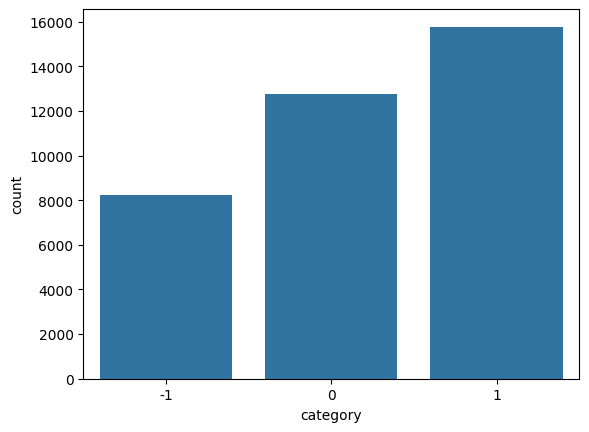

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
# distribution of classes

sns.countplot(data=df,x="category")

In [37]:
df['category'].value_counts(normalize=True).mul(100).round(2)

category
 1    42.86
 0    34.71
-1    22.42
Name: proportion, dtype: float64

In [41]:
# word count distribution in each category
df['word_count'] = df['clean_comment'].apply(lambda x: len(str(x).split()))
df.sample(5)


,clean_comment,category,comment_with_url,word_count
34247,from lakhs from 2004 2017,0,False,5
5043,yeah netas can lie affidavits and become educa...,0,False,31
25022,there this bjp supporter twitter met few month...,1,False,102
25493,this rate need subreddit for all the things ke...,1,False,12
35994,didn see this linked anywhere happening live r...,1,False,9


In [40]:
df['word_count'].describe()

count    36793.000000
mean        29.667464
std         56.790738
min          1.000000
25%          6.000000
50%         13.000000
75%         30.000000
max       1307.000000
Name: word_count, dtype: float64

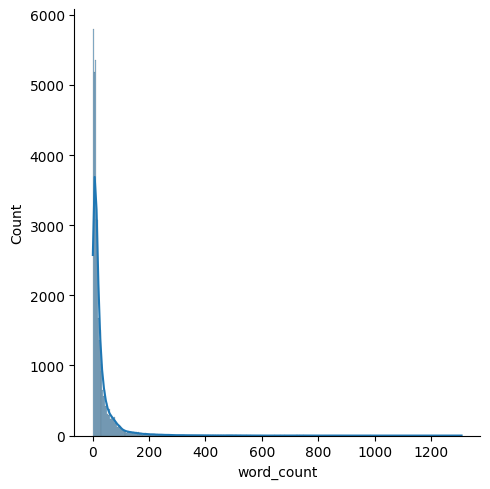

In [42]:
# distribution plot
sns.displot(df['word_count'], kde=True)

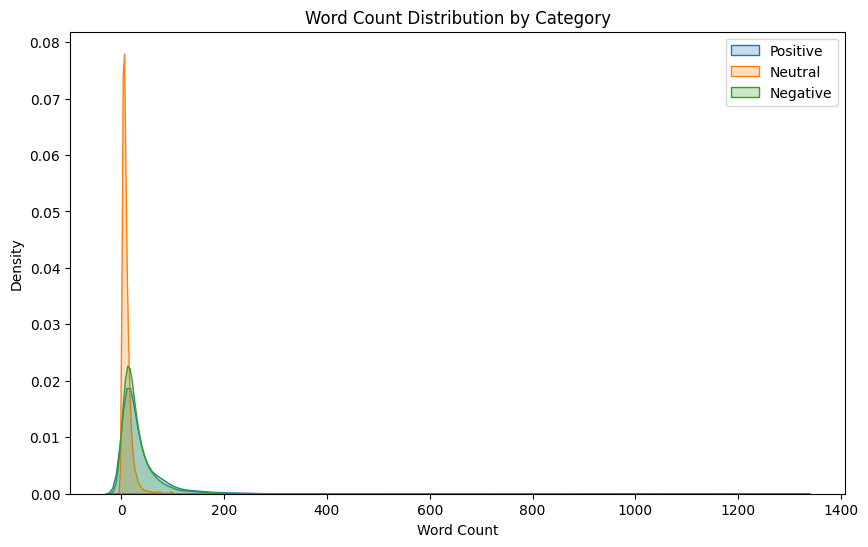

In [43]:

# Create the figure and axes
plt.figure(figsize=(10, 6))

# Plot KDE for category 1
sns.kdeplot(df[df['category'] == 1]['word_count'], label='Positive', fill=True)

# Plot KDE for category 0
sns.kdeplot(df[df['category'] == 0]['word_count'], label='Neutral', fill=True)

# Plot KDE for category -1
sns.kdeplot(df[df['category'] == -1]['word_count'], label='Negative', fill=True)

# Add title and labels
plt.title('Word Count Distribution by Category')
plt.xlabel('Word Count')
plt.ylabel('Density')

# Add a legend
plt.legend()

# Show the plot
plt.show()

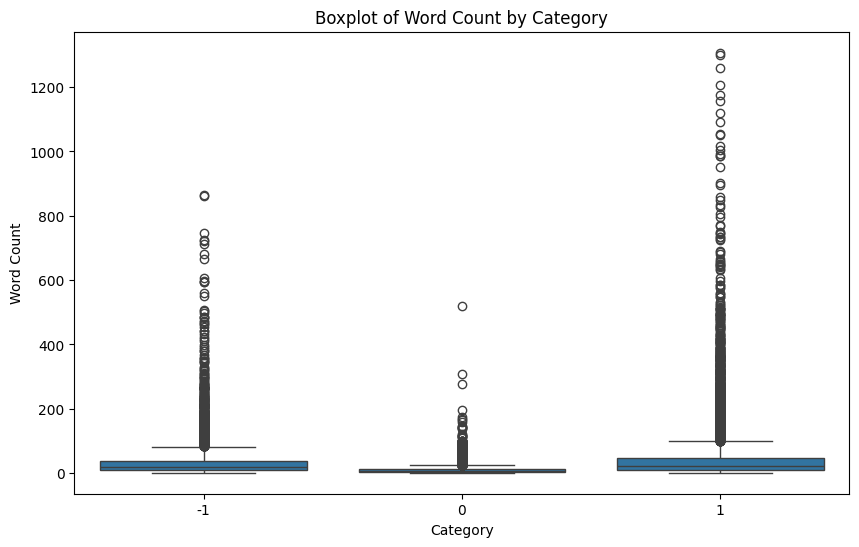

In [44]:

# Create a boxplot for the 'wordcount' column categorized by 'category'
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='category', y='word_count')
plt.title('Boxplot of Word Count by Category')
plt.xlabel('Category')
plt.ylabel('Word Count')
plt.show()

Positive comments (category 1): The median word count is relatively high, and there are several outliers with longer comments, indicating that positive comments tend to be more verbose.<br>
Neutral comments (category 0): The median word count is the lowest, with a tighter interquartile range (IQR), suggesting that neutral comments are generally shorter.<br>
Negative comments (category -1): The word count distribution is similar to positive comments but with a slightly lower median and fewer extreme outliers

<Axes: xlabel='category', ylabel='word_count'>

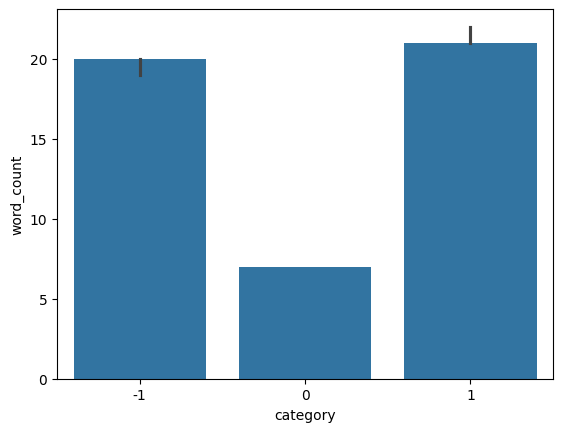

In [45]:

sns.barplot(df,x='category',y='word_count',estimator='median')
     


In [46]:

!pip install nltk

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\siddh\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [47]:
from nltk.corpus import stopwords

# Download NLTK stopwords if not already downloaded
import nltk
nltk.download('stopwords')

# Define the list of English stopwords
stop_words = set(stopwords.words('english'))



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\siddh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [48]:
# Create a new column 'num_stop_words' by counting the number of stopwords in each comment
df['num_stop_words'] = df['clean_comment'].apply(lambda x: len([word for word in x.split() if word in stop_words]))

In [49]:

df.sample(5)

,clean_comment,category,comment_with_url,word_count,num_stop_words
3161,she has good example modi,1,False,5,2
26694,scusi perché non volevi offendere tutte forze ...,0,False,13,0
13826,you should mention renamed and improved execut...,0,False,11,7
7798,from small town called junagadh near sasan gir...,-1,False,17,1
21515,sure his name now added the latest hit list bj...,1,False,11,3


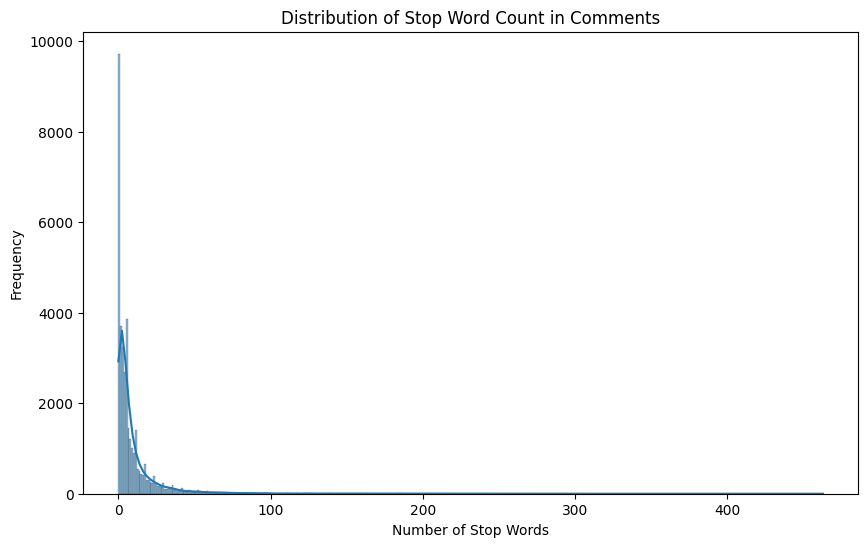

In [50]:

# Create a distribution plot (displot) for the 'num_stop_words' column
plt.figure(figsize=(10, 6))
sns.histplot(df['num_stop_words'], kde=True)
plt.title('Distribution of Stop Word Count in Comments')
plt.xlabel('Number of Stop Words')
plt.ylabel('Frequency')
plt.show()


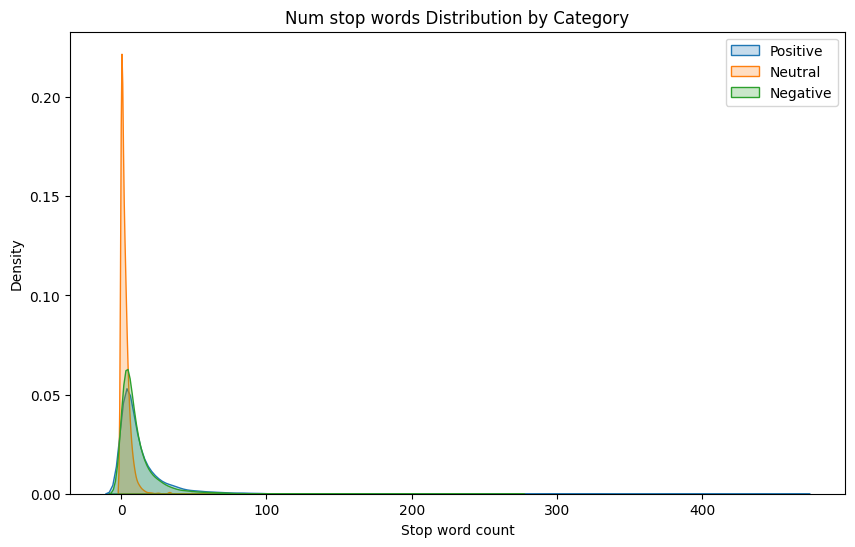

In [51]:

# Create the figure and axes
plt.figure(figsize=(10, 6))

# Plot KDE for category 1
sns.kdeplot(df[df['category'] == 1]['num_stop_words'], label='Positive', fill=True)

# Plot KDE for category 0
sns.kdeplot(df[df['category'] == 0]['num_stop_words'], label='Neutral', fill=True)

# Plot KDE for category -1
sns.kdeplot(df[df['category'] == -1]['num_stop_words'], label='Negative', fill=True)

# Add title and labels
plt.title('Num stop words Distribution by Category')
plt.xlabel('Stop word count')
plt.ylabel('Density')

# Add a legend
plt.legend()

# Show the plot
plt.show()

C:\Users\siddh\AppData\Local\Temp\ipykernel_8636\2260100725.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_df, x='count', y='stop_word', palette='viridis')


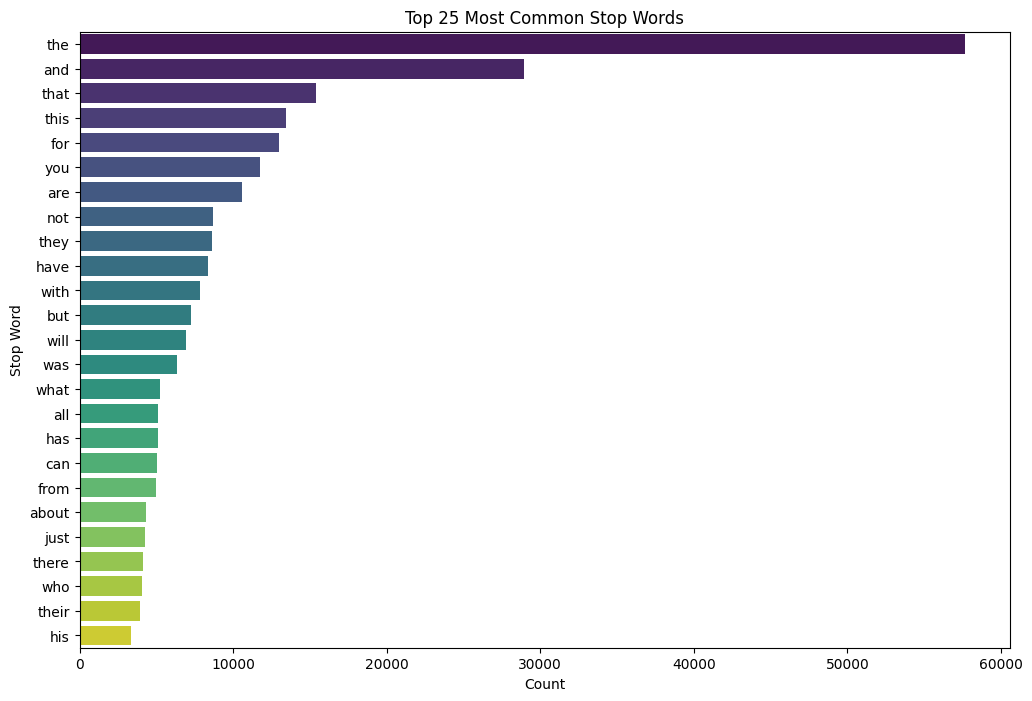

In [52]:

# Create a frequency distribution of stop words in the 'clean_comment' column
from collections import Counter

# Extract all stop words from the comments using the previously defined 'common_stopwords'
all_stop_words = [word for comment in df['clean_comment'] for word in comment.split() if word in stop_words]

# Count the most common stop words
most_common_stop_words = Counter(all_stop_words).most_common(25)

# Convert the most common stop words to a DataFrame for plotting
top_25_df = pd.DataFrame(most_common_stop_words, columns=['stop_word', 'count'])

# Create the barplot for the top 25 most common stop words
plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_df, x='count', y='stop_word', palette='viridis')
plt.title('Top 25 Most Common Stop Words')
plt.xlabel('Count')
plt.ylabel('Stop Word')
plt.show()

In [53]:
df['num_chars'] = df['clean_comment'].apply(len)

df.head()

,clean_comment,category,comment_with_url,word_count,num_stop_words,num_chars
0,family mormon have never tried explain them th...,1,False,39,13,259
1,buddhism has very much lot compatible with chr...,1,False,196,59,1268
2,seriously don say thing first all they won get...,-1,False,86,40,459
3,what you have learned yours and only yours wha...,0,False,29,15,167
4,for your own benefit you may want read living ...,1,False,112,45,690


In [54]:

df['num_chars'].describe()

count    36793.000000
mean       181.852798
std        359.702163
min          1.000000
25%         38.000000
50%         80.000000
75%        184.000000
max       8664.000000
Name: num_chars, dtype: float64

In [55]:

from collections import Counter

# Combine all comments into one large string
all_text = ' '.join(df['clean_comment'])

# Count the frequency of each character
char_frequency = Counter(all_text)

# Convert the character frequency into a DataFrame for better display
char_frequency_df = pd.DataFrame(char_frequency.items(), columns=['character', 'frequency']).sort_values(by='frequency', ascending=False)

In [56]:

char_frequency_df['character'].values

array([' ', 'e', 't', ..., '段', '她', '谁'], shape=(1378,), dtype=object)

In [57]:

# Create a new column 'num_punctuation_chars' to count punctuation characters in each comment
df['num_punctuation_chars'] = df['clean_comment'].apply(
    lambda x: sum([1 for char in x if char in '.,!?;:"\'()[]{}-'])
)

df.sample(5)

,clean_comment,category,comment_with_url,word_count,num_stop_words,num_chars,num_punctuation_chars
30863,mota bhai actually thinking ham karen karen ky...,0,False,12,0,67,0
29160,you someone who doesn understand hindi underst...,1,False,53,24,342,0
1381,please tell that item can put house and where get,0,False,10,4,49,0
28676,what the fuck our government smoking,-1,False,6,3,36,0
21861,prefer incompetence over tyranny,0,False,4,1,32,0


In [58]:

df['num_punctuation_chars'].describe()

count    36793.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: num_punctuation_chars, dtype: float64

C:\Users\siddh\AppData\Local\Temp\ipykernel_8636\1012993805.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_bigrams_df, x='count', y='bigram', palette='magma')


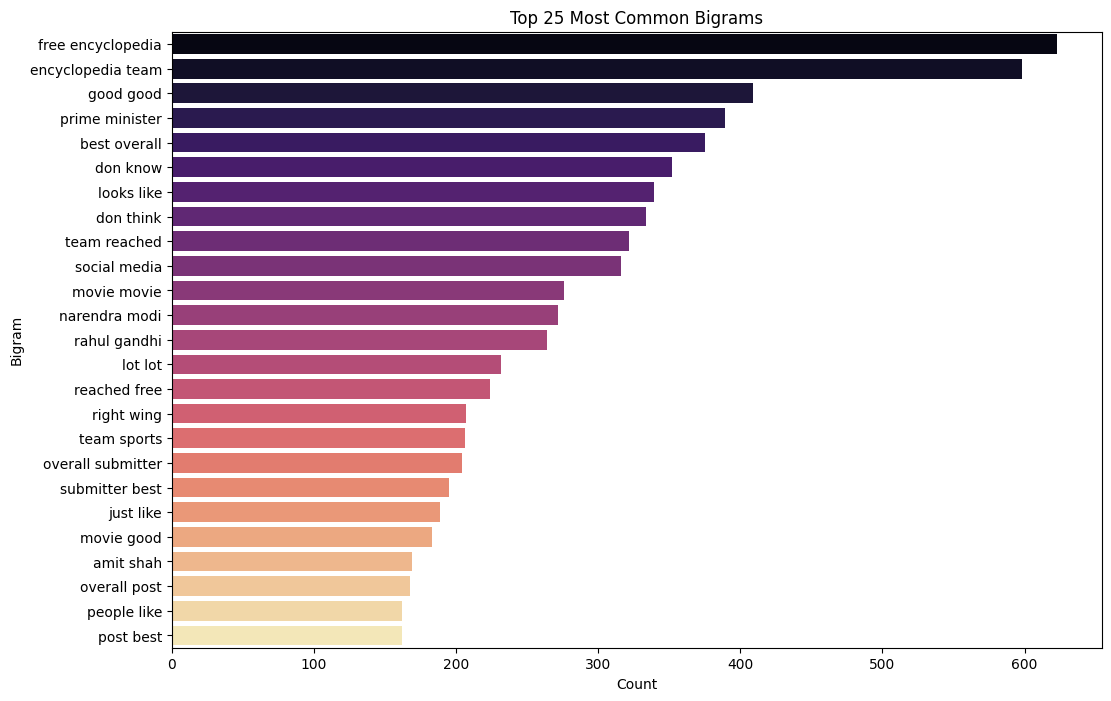

In [59]:
from sklearn.feature_extraction.text import CountVectorizer

# Create a function to extract the top 25 bigrams
def get_top_ngrams(corpus, n=None):
    vec = CountVectorizer(ngram_range=(2, 2), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

# Get the top 25 bigrams
top_25_bigrams = get_top_ngrams(df['clean_comment'], 25)

# Convert the bigrams into a DataFrame for plotting
top_25_bigrams_df = pd.DataFrame(top_25_bigrams, columns=['bigram', 'count'])

# Plot the countplot for the top 25 bigrams
plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_bigrams_df, x='count', y='bigram', palette='magma')
plt.title('Top 25 Most Common Bigrams')
plt.xlabel('Count')
plt.ylabel('Bigram')
plt.show()

C:\Users\siddh\AppData\Local\Temp\ipykernel_8636\3795620872.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_trigrams_df, x='count', y='trigram', palette='coolwarm')


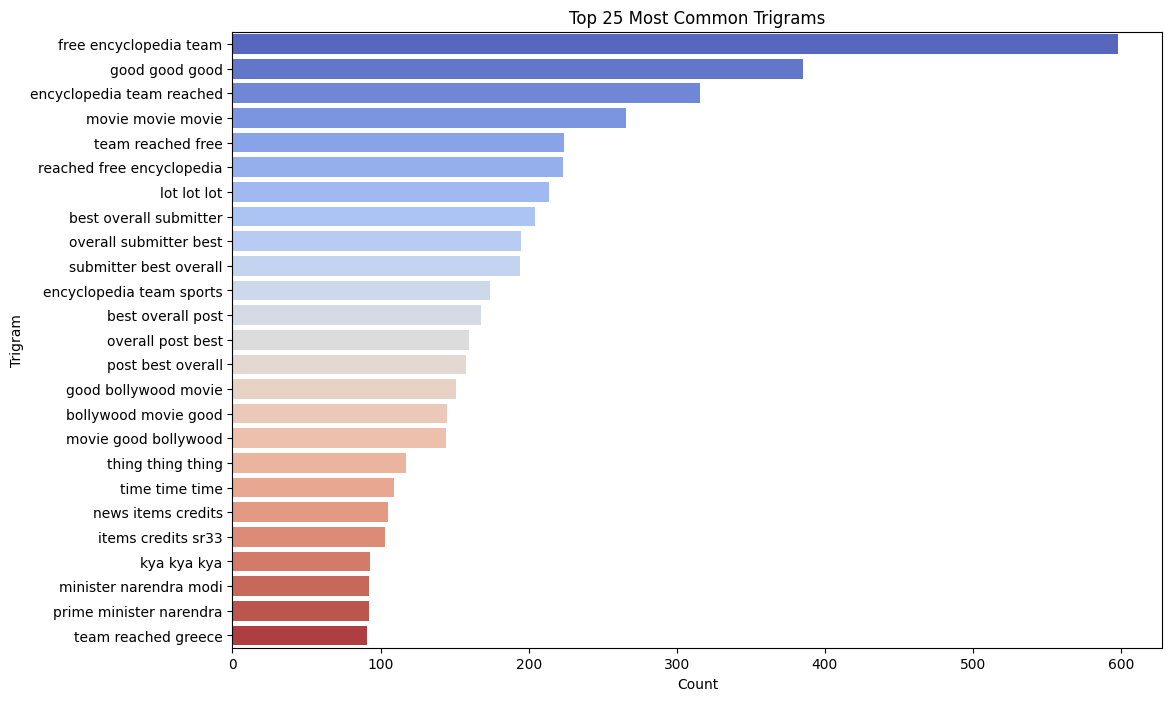

In [60]:

# Create a function to extract the top 25 trigrams
def get_top_trigrams(corpus, n=None):
    vec = CountVectorizer(ngram_range=(3, 3), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

# Get the top 25 trigrams
top_25_trigrams = get_top_trigrams(df['clean_comment'], 25)

# Convert the trigrams into a DataFrame for plotting
top_25_trigrams_df = pd.DataFrame(top_25_trigrams, columns=['trigram', 'count'])

# Plot the countplot for the top 25 trigrams
plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_trigrams_df, x='count', y='trigram', palette='coolwarm')
plt.title('Top 25 Most Common Trigrams')
plt.xlabel('Count')
plt.ylabel('Trigram')
plt.show()

In [61]:

# Remove non-English characters from the 'clean_comment' column
# Keeping only standard English letters, digits, and common punctuation
import re

df['clean_comment'] = df['clean_comment'].apply(lambda x: re.sub(r'[^A-Za-z0-9\s!?.,]', '', str(x)))

In [62]:
all_text = ' '.join(df['clean_comment'])

# Count the frequency of each character
char_frequency = Counter(all_text)

# Convert the character frequency into a DataFrame for better display
char_frequency_df = pd.DataFrame(char_frequency.items(), columns=['character', 'frequency']).sort_values(by='frequency', ascending=False)

char_frequency_df

,character,frequency
6,,1091592
12,e,666610
13,t,491287
1,a,481134
3,i,401388
9,n,388465
7,o,379908
17,s,355279
8,r,331425
10,h,296748


In [63]:
from nltk.corpus import stopwords

# Defining stop words but keeping essential ones for sentiment analysis
stop_words = set(stopwords.words('english')) - {'not', 'but', 'however', 'no', 'yet'}

# Remove stop words from 'clean_comment' column, retaining essential ones
df['clean_comment'] = df['clean_comment'].apply(
    lambda x: ' '.join([word for word in x.split() if word.lower() not in stop_words])
)


In [64]:

df.head()

,clean_comment,category,comment_with_url,word_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon never tried explain still stare ...,1,False,39,13,259,0
1,buddhism much lot compatible christianity espe...,1,False,196,59,1268,0
2,seriously say thing first get complex explain ...,-1,False,86,40,459,0
3,learned want teach different focus goal not wr...,0,False,29,15,167,0
4,benefit may want read living buddha living chr...,1,False,112,45,690,0
